<a href="https://colab.research.google.com/github/Fei-Q/dsst389/blob/main/nb/notebook13a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook13a

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c

import torch.nn as nn
import torch.optim as optim

theme_set(theme_minimal())
pl.Config(tbl_rows=25)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
!wget https://humanitiesdata.org/media/fashionmnist_10000.tar -P media/
!tar -xf media/fashionmnist_10000.tar -C media/

--2026-03-30 13:50:00--  https://humanitiesdata.org/media/fashionmnist_10000.tar
Resolving humanitiesdata.org (humanitiesdata.org)... 51.222.48.183
Connecting to humanitiesdata.org (humanitiesdata.org)|51.222.48.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23183360 (22M) [application/x-tar]
Saving to: ‘media/fashionmnist_10000.tar’

fashionmnist_10000. 100%[===================>]  22.11M  7.00MB/s    in 3.2s    

2026-03-30 13:50:05 (7.00 MB/s) - ‘media/fashionmnist_10000.tar’ saved [23183360/23183360]



In [4]:
fmnist = pl.read_csv(ub + "data/fashionmnist_10000.csv")
fmnist

label,filepath,index
str,str,str
"""dress""","""media/fashionmnist_10000/00000…","""test"""
"""shirt""","""media/fashionmnist_10000/00001…","""test"""
"""pullover""","""media/fashionmnist_10000/00002…","""train"""
"""pullover""","""media/fashionmnist_10000/00003…","""test"""
"""ankle boot""","""media/fashionmnist_10000/00004…","""train"""
"""pullover""","""media/fashionmnist_10000/00005…","""train"""
"""trouser""","""media/fashionmnist_10000/00006…","""train"""
"""ankle boot""","""media/fashionmnist_10000/00007…","""train"""
"""ankle boot""","""media/fashionmnist_10000/00008…","""train"""


### Part I: Supervised and Unsupervised Learning

1. Let's start by getting a feel for the Fashion MNIST dataset. Use `DSImage.plot_image_grid` to display a random sample of 30 images in a grid with 10 columns.

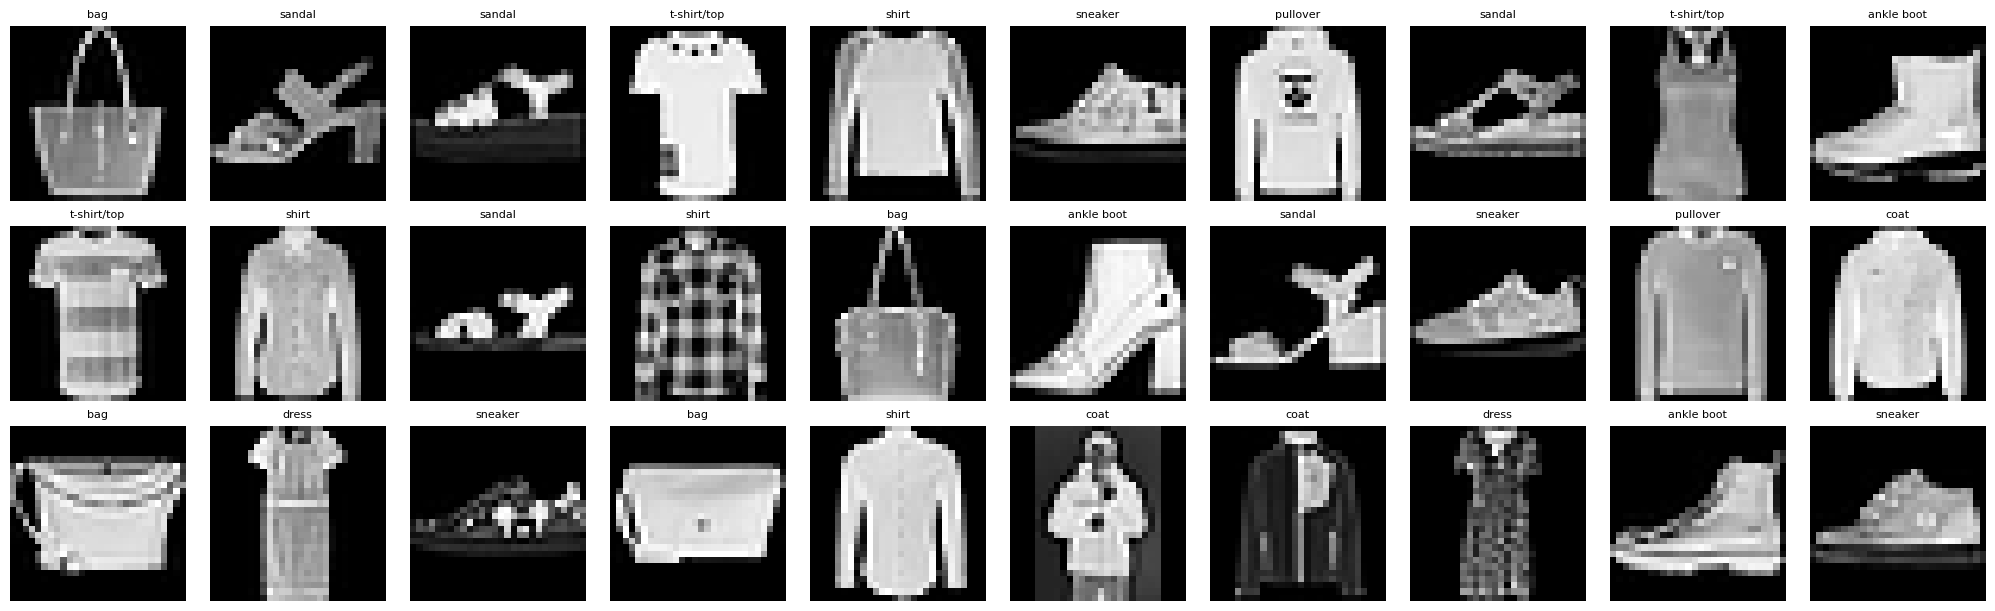

In [5]:
DSImage.plot_image_grid(fmnist.sample(30), ncol=10)

2. Filter the dataset to only the "sneaker" label, take a random sample of 30, and display the images in a grid. This gives us a sense of what a single category looks like.

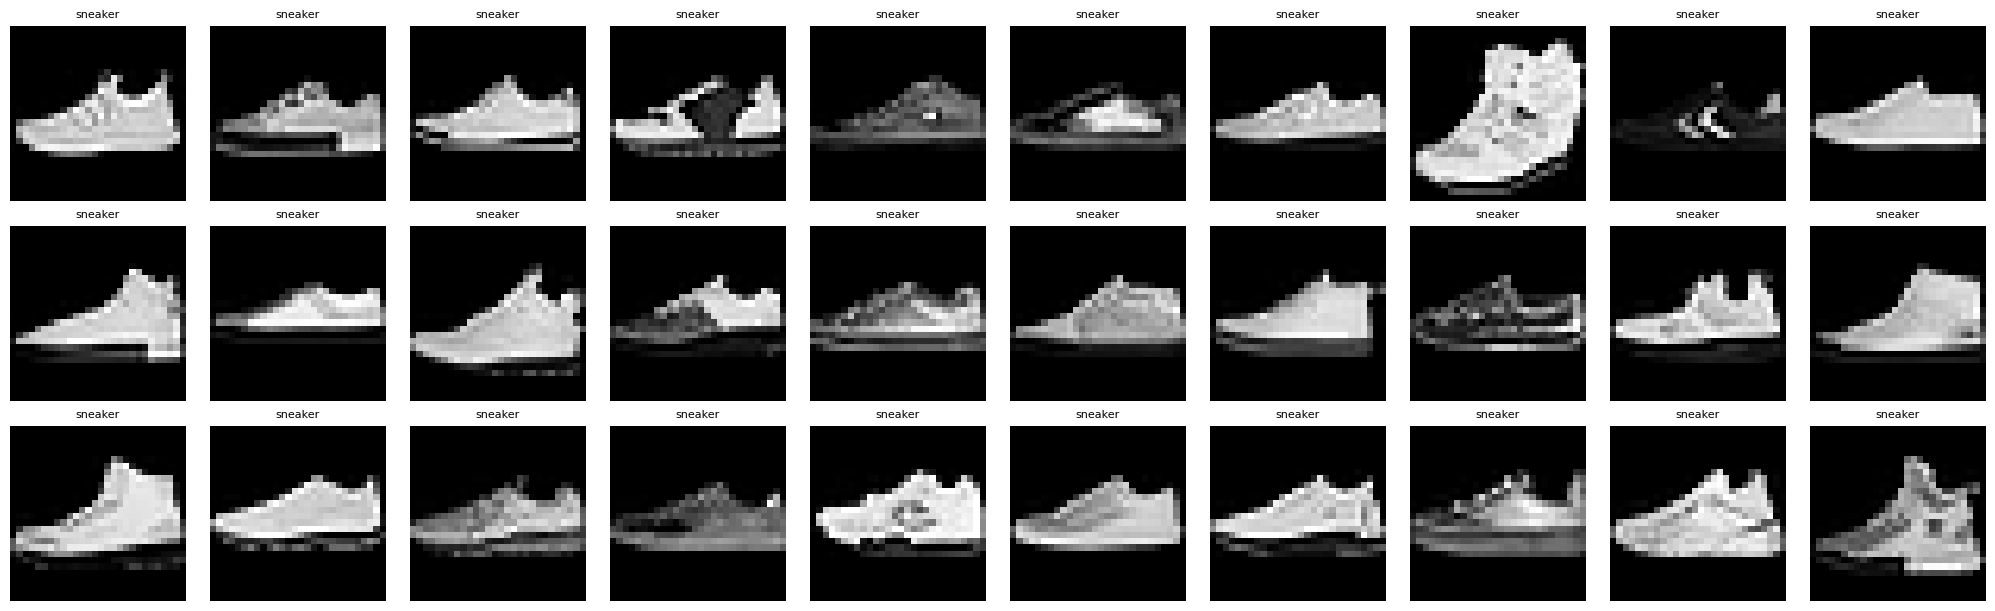

In [6]:
(
    fmnist
    .filter(c.label == "sneaker")
    .sample(30)
    .pipe(DSImage.plot_image_grid, ncol=10)
)

3. Use `DSTorch.load_image` to prepare the image data for modeling. Set `scale=True` and `flatten=True`. This returns the full feature matrices (`X`, `X_train`, `X_test`), label vectors (`y`, `y_train`, `y_test`), and the class names (`cn`).

In [7]:
X, X_train, X_test, y, y_train, y_test, cn = DSTorch.load_image(
    fmnist, scale=True, flatten=True
)

4. This code shows how to add the matrix data directly into a data frame object. Run it and make sure you understand how it works. We will use it in the next few examples.

In [8]:
(
    fmnist
    .with_columns(
        pixels = pl.Series("features", X.numpy().tolist())
    )
)

label,filepath,index,pixels
str,str,str,list[f64]
"""dress""","""media/fashionmnist_10000/00000…","""test""","[0.0, 0.0, … 0.0]"
"""shirt""","""media/fashionmnist_10000/00001…","""test""","[0.0, 0.0, … 0.0]"
"""pullover""","""media/fashionmnist_10000/00002…","""train""","[0.0, 0.0, … 0.0]"
"""pullover""","""media/fashionmnist_10000/00003…","""test""","[0.0, 0.0, … 0.0]"
"""ankle boot""","""media/fashionmnist_10000/00004…","""train""","[0.0, 0.0, … 0.0]"
"""pullover""","""media/fashionmnist_10000/00005…","""train""","[0.0, 0.0, … 0.0]"
"""trouser""","""media/fashionmnist_10000/00006…","""train""","[0.0, 0.0, … 0.0]"
"""ankle boot""","""media/fashionmnist_10000/00007…","""train""","[0.0, 0.0, … 0.0]"
"""ankle boot""","""media/fashionmnist_10000/00008…","""train""","[0.0, 0.0, … 0.0]"


5. Let's visualize how the different clothing categories relate to each other. Add the pixel features as a column, take 10 images from each label, run UMAP (an unsupervised dimensionality reduction method) using `DSSklearn.umap` with `features=[c.pixels]`, call `.predict(full=True)`, and plot the result using `geom_text` with the label as the text. Which categories cluster together?

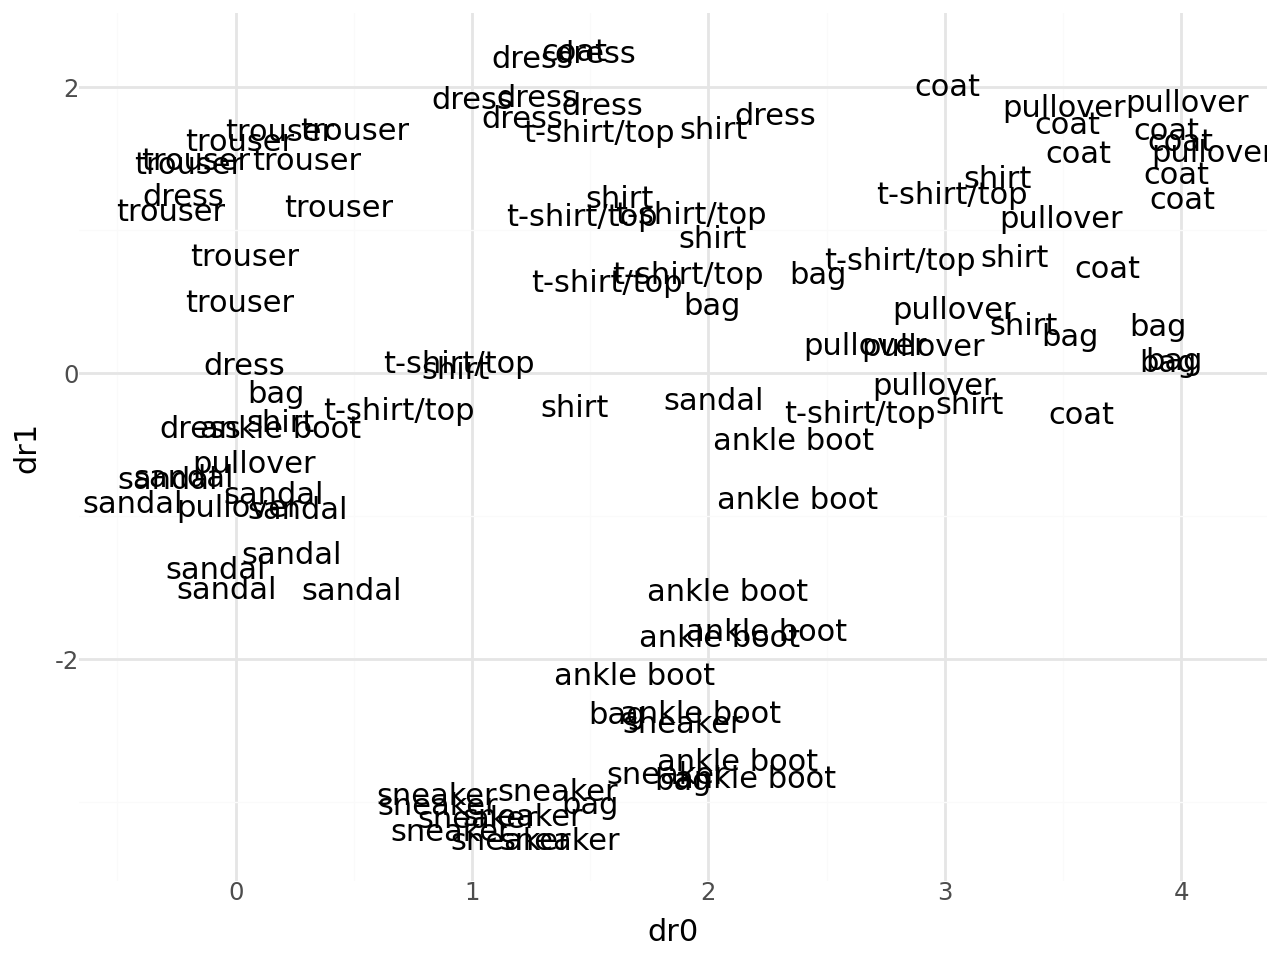

In [9]:
(
    fmnist
    .with_columns(
        pixels = pl.Series("features", X.numpy().tolist())
    )
    .group_by(c.label)
    .head(10)
    .pipe(
        DSSklearn.umap,
        features=[c.pixels]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_text(aes(label="label"))
)

6. Now let's try a supervised approach. Add the pixel features as a column, then use `DSSklearn.logistic_regression_cv` with `target=c.label`, `stratify=c.label`, `features=[c.pixels]`, and `l1_ratios=[0]`. This fits a regularized logistic regression with cross-validation. Save the result as `model`.

In [10]:
model = (
    fmnist
    .with_columns(
        pixels = pl.Series("features", X.numpy().tolist())
    )
    .pipe(
        DSSklearn.logistic_regression_cv,
        target=c.label,
        stratify=c.label,
        features=[c.pixels],
        l1_ratios=[0]
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1863: UserWarning: l1_ratios parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documen

7. Check the accuracy of the logistic regression model using `.score()`.

In [11]:
model.score()

{'train': 0.8797142857142857, 'test': 0.8536666666666667}

8. Display the confusion matrix to see which categories the model tends to mix up.

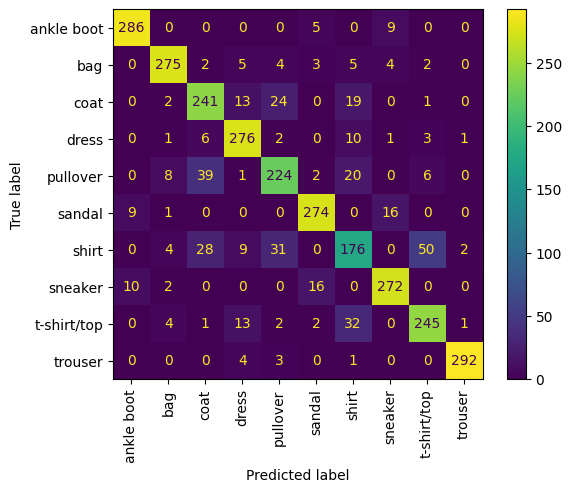

In [12]:
model.confusion_matrix()

### Part II: Deep Learning

9. Now let's build a neural network. Define a `DenseNet` class that follows the same structure from the notes: a sequential network with a linear layer from 784 to 128 units, ReLU activation, a linear layer from 128 to 64, ReLU activation, and a final linear layer from 64 to 10 (one per class). Try to adapt the parameters to see if you can improve the results.

In [13]:
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

10. Create an instance of your `DenseNet` model and set up the Adam optimizer with a learning rate of 0.001, as in the notes. You can try adjusting the learning rate later to see how it affects training.

In [14]:
model = DenseNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

11. Train the model using `DSTorch.train` with the training data. Start with `num_epochs=20` and `batch_size=64` as in the notes. You can experiment with different values to try to improve performance.

In [15]:
DSTorch.train(
    model, optimizer, X_train, y_train, num_epochs=20, batch_size=64
)

Epoch 1/20, Loss: 1.0570
Epoch 2/20, Loss: 0.6072
Epoch 3/20, Loss: 0.5172
Epoch 4/20, Loss: 0.4836
Epoch 5/20, Loss: 0.4420
Epoch 6/20, Loss: 0.4249
Epoch 7/20, Loss: 0.4026
Epoch 8/20, Loss: 0.3735
Epoch 9/20, Loss: 0.3581
Epoch 10/20, Loss: 0.3573
Epoch 11/20, Loss: 0.3363
Epoch 12/20, Loss: 0.3249
Epoch 13/20, Loss: 0.3103
Epoch 14/20, Loss: 0.3149
Epoch 15/20, Loss: 0.2961
Epoch 16/20, Loss: 0.2817
Epoch 17/20, Loss: 0.2722
Epoch 18/20, Loss: 0.2613
Epoch 19/20, Loss: 0.2617
Epoch 20/20, Loss: 0.2496


12. Score the model on both the training set and the test set using `DSTorch.score_image`. Compare the two — how much does accuracy drop on the test set? If there is a big gap, the model may be overfitting.

In [16]:
DSTorch.score_image(model, X_train, y_train, cn)

0.9014666676521301

In [17]:
DSTorch.score_image(model, X_test, y_test, cn)

0.8468000292778015

13. Display the confusion matrix for the neural network on the test set. Compare it with the logistic regression confusion matrix from question 8 — does the neural network do better on certain categories?

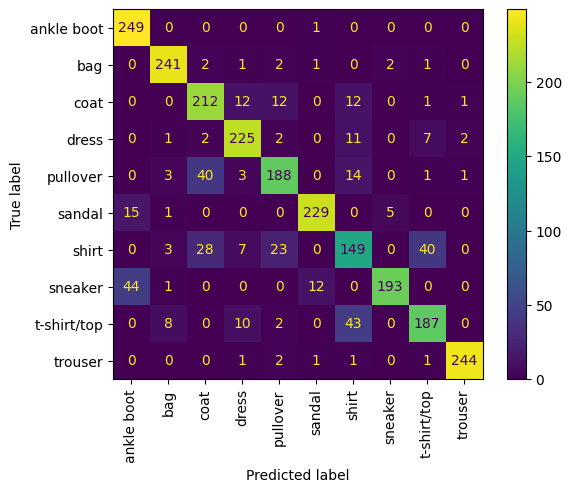

In [18]:
DSTorch.confusion_matrix(model, X_test, y_test, cn)